In [1]:
import sys
sys.path.insert(0, '../../mitsuba3/build/python')

from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

import drjit as dr
import mitsuba as mi

mi.set_variant('cuda_ad_rgb')

## Define original sphere to map

In [2]:
res = 100
theta = dr.linspace(mi.Float, 0, dr.pi/2 + 0.01*dr.pi, res)
phi = dr.linspace(mi.Float, 0, 2 * dr.pi, res)
theta, phi = dr.meshgrid(theta, phi)
st, ct = dr.sincos(theta)
sp, cp = dr.sincos(phi)

wi = mi.Vector3f(st * cp, st * sp, ct)
dr.eval(wi)

True

## Test a warp

In [3]:
def pdf_cosine_hemisphere(wi):
    return dr.inv_pi * dr.maximum(0.0, mi.Frame3f.cos_theta(wi))

def pdf_uniform_hemisphere(wi):
    return dr.inv_two_pi & (mi.Frame3f.cos_theta(wi) > 0.0)

def pdf_pow_cosine_hemisphere(wi, exp):
    return (1+exp) * mi.Frame3f.sin_theta(wi) * mi.Frame3f.cos_theta(wi) ** exp

def pdf_uniform_sphere(wi):
    return dr.inv_four_pi

def pdf(pdf_func, wi, mat):
    inv_mat = dr.rcp(mat)
    im_wi = inv_mat @ wi
    norm = dr.norm(im_wi)
    return dr.abs(dr.det(inv_mat)) * pdf_func(im_wi / norm) / (norm * norm * norm)

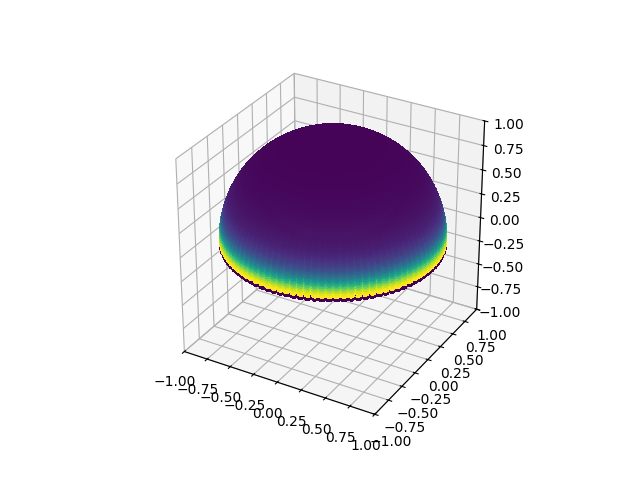

In [4]:
mat = mi.Matrix3f(
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.2]
)
pdf_out = pdf(pdf_uniform_hemisphere, wi, mat)

dr.eval(pdf_out)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(wi.x, wi.y, wi.z, c=pdf_out, antialiased=False, depthshade=False)
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()


## Setup optimization

In [12]:
from vizsky_contrib import load_tensors, interpolate_dataset, eval_luminance, eval

class SkyFitter:

    DRJIT_STRUCT = { 
        'sky_rad' : mi.TensorXf,
        'sky_params' : mi.TensorXf,
        'sun_dir' : mi.Vector3f, 
        'tex_pos' : mi.Point2f, 
        'lum_map': mi.Float 
    }

    def __init__(self, sky_rad_dataset, sky_params_dataset, turb, sun_eta, sun_phi=dr.pi/2):
        dr.make_opaque(turb, sun_eta)
        self.turb = turb
        self.sun_eta = sun_eta

        self.sky_rad = interpolate_dataset(sky_rad_dataset, 0.5, turb, sun_eta)
        self.sky_params = interpolate_dataset(sky_params_dataset, 0.5, turb, sun_eta)
        self.tex_pos = mi.Point2f((turb - 1) / 10, (dr.rad2deg(sun_eta) - 2) / (98-2))
        
        sun_theta = dr.pi / 2 - sun_eta
        st, ct = dr.sincos(sun_theta)
        sp, cp = dr.sincos(sun_phi)
        self.sun_dir = mi.Vector3f(st * cp, st * sp, ct)
        dr.eval(self.sky_rad, self.sky_params, self.sun_dir)

        
        self.lum_map = self._get_luminance_map()
        dr.eval(self.lum_map)

    def loss(self, tex_weights, wi):
        approx_pdf = self.approximate_pdf(tex_weights, wi)
        return (self.lum_map - approx_pdf)**2
    
    def approximate_pdf(self, tex_weights, wi):
        weights = tex_weights.eval(self.tex_pos)
        inv_mat = mi.Matrix3f([
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, weights[0]]
        ])
        im_wi = inv_mat @ wi
        norm = dr.norm(im_wi)
        return dr.abs(dr.det(inv_mat)) * pdf_uniform_hemisphere(im_wi / norm) / (norm * norm * norm)
    

    def viz_loss(self, tex_weights, wi):
        # lum_map = np.reshape(self.lum_map, (res, res)).T
        # pdf = np.reshape(self.approximate_pdf(tex_weights, wi), (res, res)).T

        # rel_error = np.abs(lum_map - pdf) / np.maximum(lum_map, 1e-8)

        # fig, ax = plt.subplots(1, 3, figsize=(18, 6))
        # im1 = ax[0].imshow(lum_map)
        # ax[0].set_title("Luminance Map")
        # plt.colorbar(im1, ax=ax[0])

        # im2 = ax[1].imshow(pdf)
        # ax[1].set_title("Approximate PDF Map")
        # plt.colorbar(im2, ax=ax[1])

        # im2 = ax[2].imshow(rel_error, vmin=0, vmax=1)
        # ax[2].set_title("Relative Error Map")
        # plt.colorbar(im2, ax=ax[2])
        # plt.show()

        # Plotting
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': '3d'})

        pdf_out = self.approximate_pdf(tex_weights, wi)

        ax[0].scatter(wi.x, wi.y, wi.z, c=self.lum_map, antialiased=False, depthshade=False)
        ax[0].set_box_aspect([1,1,1])  # Equal aspect ratio
        ax[0].set_xlim(-1, 1)
        ax[0].set_ylim(-1, 1)
        ax[0].set_zlim(-1, 1)

        ax[1].scatter(wi.x, wi.y, wi.z, c=pdf_out, antialiased=False, depthshade=False)
        ax[1].set_box_aspect([1,1,1])  # Equal aspect ratio
        ax[1].set_xlim(-1, 1)
        ax[1].set_ylim(-1, 1)
        ax[1].set_zlim(-1, 1)   
        plt.show()

    
    
    def _get_luminance_map(self):

        ## Evaluate raw luminance map     
        cos_theta = mi.Frame3f.cos_theta(wi)
        gamma = dr.unit_angle(wi, self.sun_dir)
        
        sky_lum_map = eval_luminance(eval, self.sky_rad, self.sky_params, cos_theta, gamma) * dr.safe_sqrt(1 - cos_theta**2)


        ## Integrate to get total luminance
        quad_points, quad_weights = mi.quad.gauss_legendre(200)
        ct = quad_points
        phi = 2*dr.pi * quad_points
        ct, phi = dr.meshgrid(ct, phi)
        phi_weights, ct_weights = dr.meshgrid(quad_weights, quad_weights)

        st = dr.safe_sqrt(1 - ct**2)
        sp, cp = dr.sincos(phi)
        dirs = mi.Vector3f(st * cp, st * sp, ct)

        cos_theta = ct
        gamma = dr.unit_angle(dirs, self.sun_dir)

        total_lum = eval_luminance(eval, self.sky_rad, self.sky_params, cos_theta, gamma) * dr.safe_sqrt(1 - cos_theta**2)
        total_lum = dr.sum(total_lum * phi_weights * ct_weights, axis=0) * 2 * dr.pi

        ## Return normalized map for valid pdf
        return dr.select(total_lum > 0, sky_lum_map / total_lum, 0.0)


Loading tensor data from "../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin" .. (540.0 KiB, 7 fields)
Created 1200 sky fitters


Loss: [9.25736]: 100%|██████████| 1000/1000 [01:22<00:00, 12.16it/s]


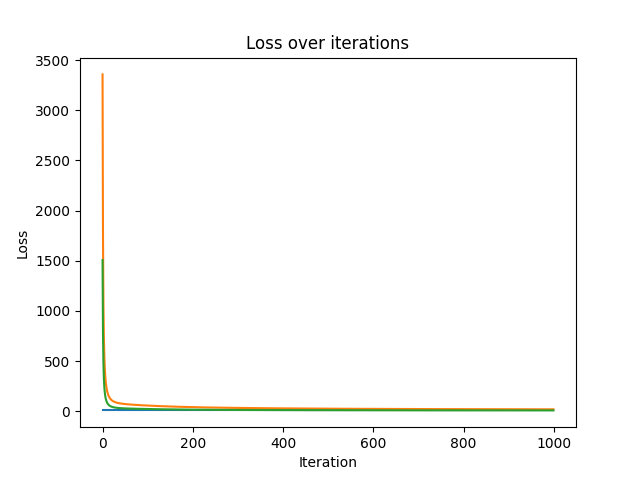

In [13]:
sky_rad_dataset, sky_params_dataset = load_tensors('../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin')

def generate_fitters(turb_res, sun_eta_res):
    fitters = []
    for t in np.linspace(1.0, 10.0, turb_res):
        for sun_eta in np.linspace(dr.deg2rad(2), dr.deg2rad(98), sun_eta_res):
            fitters.append(SkyFitter(sky_rad_dataset, sky_params_dataset, float(t), float(sun_eta)))
    return fitters

sky_fitters = generate_fitters(20, 60)
dr.print("Created {} sky fitters", len(sky_fitters))


@dr.freeze
def loss_function(tex_weights, sky_fitters, wi):
    total_err = 0.0
    for fitter in sky_fitters:
        total_err += fitter.loss(tex_weights, wi)

    loss = dr.mean(total_err)
    dr.backward(loss)

    return loss

## Generate initial weights
turb_res = 10
sun_eta_res = 30
rng = dr.rng(42)
#weights = rng.normal(mi.TensorXf, (turb_res, sun_eta_res, 4), loc=0.0, scale=1.5)
weights = dr.ones(mi.TensorXf, (turb_res, sun_eta_res, 1)) * 0.2

dr.eval(weights)
tex_weights = mi.Texture2f(weights, 
                           wrap_mode=dr.WrapMode.Clamp,
                           migrate=False)

opt = mi.ad.Adam(lr=0.05)
opt_key = "weights"
opt[opt_key] = weights

## Optimize
losses = []
iterations = trange(1000)
for it in iterations:
    opt[opt_key] = dr.maximum(1e-3, opt[opt_key])
    tex_weights.set_tensor(opt[opt_key])

    
    loss = loss_function(tex_weights, sky_fitters, wi)

    opt.step()
    iterations.set_description(f"Loss: {loss}")

    losses.append(loss)

optimal_weights = opt[opt_key]

plt.close()
plt.plot(losses)
plt.title('Loss over iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

Worst fitter turb: 8.10526, sun_eta: 0.233697
Parameter weights: [
  [1.53368]
]


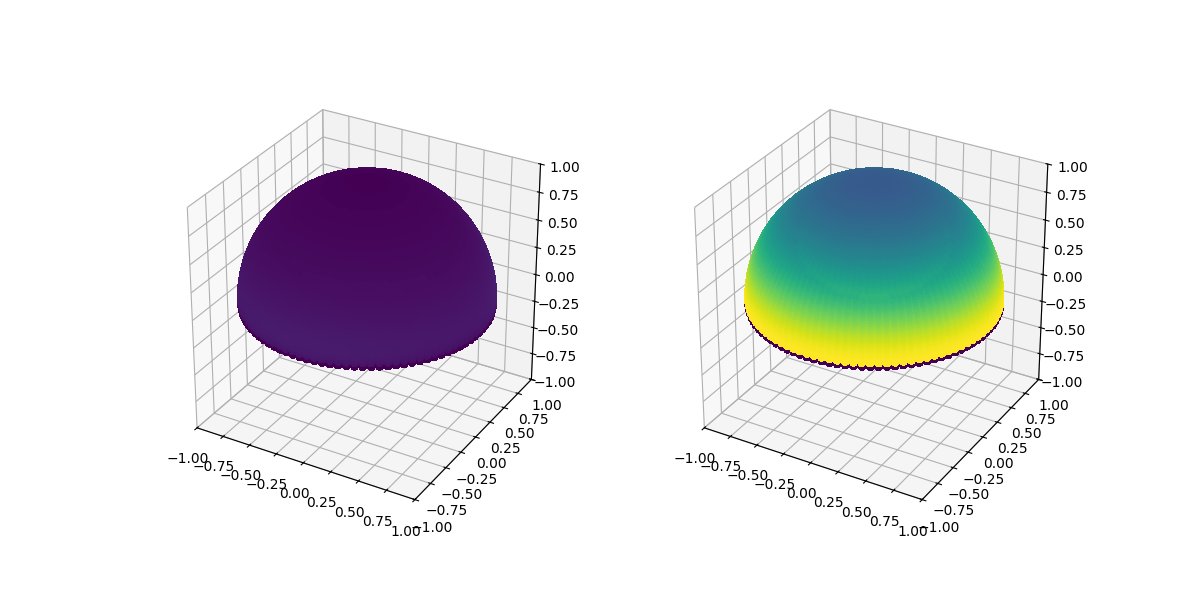

In [14]:
worse_fitter = max(sky_fitters, key=lambda f: dr.mean(f.loss(tex_weights, wi)))

dr.print("Worst fitter turb: {}, sun_eta: {}", worse_fitter.turb, worse_fitter.sun_eta)
dr.print("Parameter weights: {}", tex_weights.eval(worse_fitter.tex_pos))
worse_fitter.viz_loss(tex_weights, wi)